In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

In [2]:
df = pd.read_csv("cleaned_final.csv")
df.head()

,Дата,Коррупция,Взятка,приговор,дело,Хищение,расследование,Задержание,Получение,Преступление,...,судебный,процесс,аким,начальник,заместитель,район,город,область,правонарушение,Всего коррупционных преступлений
0,2016-12-01,8.0,3.0,4.0,13,1.0,4.0,3.0,1,2.0,...,1.0,2.0,4.0,1.0,3.0,1.0,1.0,3.0,2.0,3214
1,2017-01-01,41.0,29.0,1.0,30,1.0,14.0,16.0,21,4.0,...,7.0,4.0,9.0,5.0,16.0,13.0,3.0,14.0,2.0,1137
2,2017-02-01,24.0,16.0,15.0,55,19.0,16.0,10.0,15,10.0,...,2.0,1.0,3.0,6.0,3.0,3.0,9.0,14.0,3.0,1337
3,2017-03-01,33.0,26.0,10.0,73,24.0,26.0,8.0,17,30.0,...,12.0,4.0,13.0,2.0,18.0,17.0,12.0,23.0,7.0,1566
4,2017-04-01,42.0,22.0,4.0,48,13.0,10.0,1.0,15,11.0,...,12.0,3.0,2.0,10.0,18.0,2.0,9.0,18.0,5.0,1802


In [3]:
df["Дата"] = pd.to_datetime(df["Дата"])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Дата                              88 non-null     datetime64[ns]
 1   Коррупция                         88 non-null     float64       
 2   Взятка                            88 non-null     float64       
 3   приговор                          88 non-null     float64       
 4   дело                              88 non-null     int64         
 5   Хищение                           88 non-null     float64       
 6   расследование                     88 non-null     float64       
 7   Задержание                        88 non-null     float64       
 8   Получение                         88 non-null     int64         
 9   Преступление                      88 non-null     float64       
 10  миллиард                          88 non-null     fl

In [5]:
df.tail()

,Дата,Коррупция,Взятка,приговор,дело,Хищение,расследование,Задержание,Получение,Преступление,...,судебный,процесс,аким,начальник,заместитель,район,город,область,правонарушение,Всего коррупционных преступлений
83,2024-07-01,28.0,24.0,29.0,49,30.0,26.0,7.0,20,3.0,...,9.0,5.0,7.0,12.0,7.0,2.0,3.0,31.0,6.0,1200
84,2024-08-01,10.0,16.0,20.0,23,10.0,10.0,2.0,6,5.0,...,7.0,5.0,5.0,3.0,7.0,7.0,4.0,19.0,5.0,1246
85,2024-09-01,20.0,16.0,14.0,32,12.0,2.0,13.0,12,4.0,...,4.0,6.0,23.0,3.0,9.0,13.0,6.0,22.0,3.0,1300
86,2024-10-01,21.0,13.0,3.0,29,5.0,7.0,1.0,9,3.0,...,4.0,4.0,7.0,4.0,4.0,9.0,7.0,18.0,4.0,1358
87,2024-11-01,11.0,26.0,15.0,12,4.0,16.0,5.0,13,3.0,...,4.0,1.0,6.0,14.0,2.0,6.0,5.0,25.0,7.0,1415


Корреляция с целевой переменной:
Всего коррупционных преступлений    1.000000
Преступление                        0.249795
Коррупция                           0.243810
Получение                           0.168645
расследование                       0.146811
город                               0.140829
заместитель                         0.136782
область                             0.110399
аким                                0.100121
район                               0.099279
дело                                0.096394
Взятка                              0.076197
начальник                           0.075152
миллион                             0.043835
приговор                            0.012539
Хищение                            -0.002762
Задержание                         -0.022683
судебный                           -0.023967
правонарушение                     -0.025228
процесс                            -0.153070
миллиард                           -0.204068
Дата                  

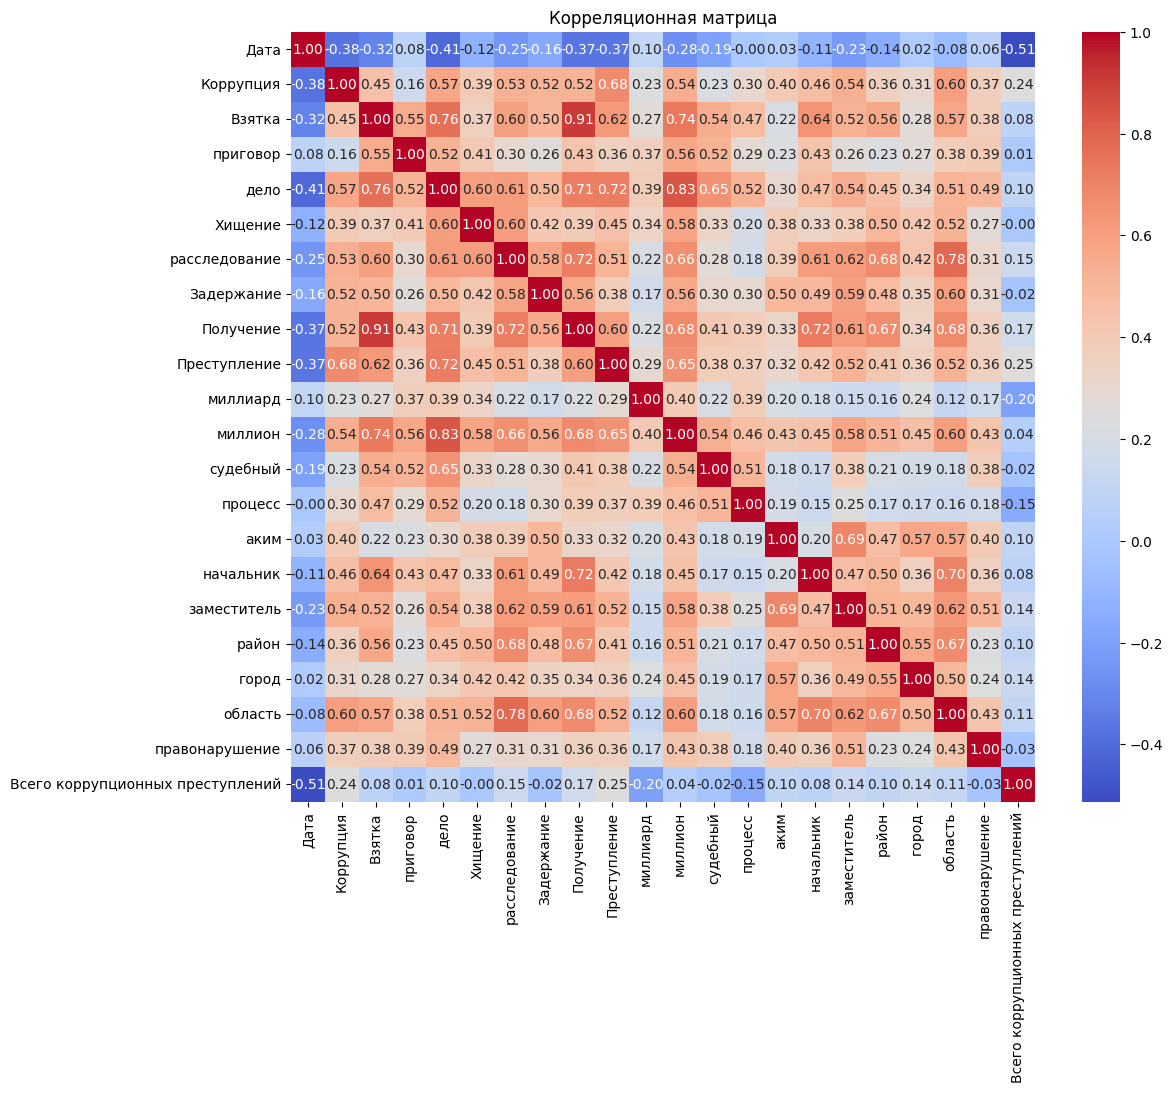

In [6]:
# Вычисляем корреляцию
correlation_matrix = df.corr()

# Выводим корреляцию целевой переменной с другими признаками
target_corr = correlation_matrix["Всего коррупционных преступлений"].sort_values(ascending=False)
print("Корреляция с целевой переменной:")
print(target_corr)

# Визуализируем корреляционную матрицу
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Корреляционная матрица")
plt.show()

In [7]:
# Создаём новый датафрейм с агрегированными признаками
df_agg = pd.DataFrame()

# Агрегированные признаки
df_agg['Коррупция_сумма'] = df[['Коррупция', 'Взятка', 'Получение', 'Хищение', 'правонарушение']].sum(axis=1)
df_agg['Власть_сумма'] = df[['район', 'город', 'область', 'аким', 'начальник', 'заместитель']].sum(axis=1)
df_agg['Финансы_сумма'] = df[['миллион', 'миллиард']].sum(axis=1)

# Добавляем временные компоненты
df_agg['Месяц'] = pd.to_datetime(df['Дата']).dt.month
df_agg['Год'] = pd.to_datetime(df['Дата']).dt.year

# Целевая переменная
df_agg['Всего коррупционных преступлений'] = df['Всего коррупционных преступлений']
df_agg


,Коррупция_сумма,Власть_сумма,Финансы_сумма,Месяц,Год,Всего коррупционных преступлений
0,15.0,13.0,8.0,12,2016,3214
1,94.0,60.0,20.0,1,2017,1137
2,77.0,38.0,51.0,2,2017,1337
3,107.0,85.0,57.0,3,2017,1566
4,97.0,59.0,29.0,4,2017,1802
...,...,...,...,...,...,...
83,108.0,62.0,42.0,7,2024,1200
84,47.0,45.0,33.0,8,2024,1246
85,63.0,76.0,29.0,9,2024,1300
86,52.0,49.0,33.0,10,2024,1358


In [8]:
# 1. Для исходного датафрейма df
low_corr_features = ["Хищение", "судебный", "правонарушение", "приговор", "процесс"]
X_df = df.drop(columns=["Всего коррупционных преступлений", "Дата"] + low_corr_features)
y_df = df["Всего коррупционных преступлений"]

X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X_df, y_df, test_size=0.2, random_state=42)

# 2. Для агрегированного датафрейма df_agg
X_agg = df_agg.drop(columns=["Всего коррупционных преступлений"])
y_agg = df_agg["Всего коррупционных преступлений"]

X_train_agg, X_test_agg, y_train_agg, y_test_agg = train_test_split(X_agg, y_agg, test_size=0.2, random_state=42)

In [9]:
# Функция для обучения и оценки модели
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name}:")
    print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, R2: {r2:.2f}")
    print("-" * 30)

In [10]:
# Список моделей
models = [
    ("Linear Regression", LinearRegression()),
    ("Ridge Regression", Ridge(alpha=1.0)),
    ("Lasso Regression", Lasso(alpha=0.1)),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ("Random Forest Regressor", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting Regressor", GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ("XGBoost Regressor", xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42))
]

In [11]:
# Обучение и оценка для df
print("Оценка моделей на df:")
for name, model in models:
    evaluate_model(model, X_train_df, X_test_df, y_train_df, y_test_df, name)

# Обучение и оценка для df_agg
print("Оценка моделей на df_agg:")
for name, model in models:
    evaluate_model(model, X_train_agg, X_test_agg, y_train_agg, y_test_agg, name)

Оценка моделей на df:
Linear Regression:
MAE: 592.65, MSE: 526130.04, R2: -0.09
------------------------------
Ridge Regression:
MAE: 592.33, MSE: 525747.53, R2: -0.08
------------------------------
Lasso Regression:
MAE: 592.60, MSE: 526054.30, R2: -0.09
------------------------------
ElasticNet:
MAE: 591.54, MSE: 524766.74, R2: -0.08
------------------------------
Random Forest Regressor:
MAE: 585.58, MSE: 466639.65, R2: 0.04
------------------------------
Gradient Boosting Regressor:
MAE: 534.77, MSE: 398756.43, R2: 0.18
------------------------------
XGBoost Regressor:
MAE: 496.80, MSE: 382289.12, R2: 0.21
------------------------------
Оценка моделей на df_agg:
Linear Regression:
MAE: 171.96, MSE: 54610.94, R2: 0.89
------------------------------
Ridge Regression:
MAE: 172.02, MSE: 54607.22, R2: 0.89
------------------------------
Lasso Regression:
MAE: 171.96, MSE: 54607.66, R2: 0.89
------------------------------
ElasticNet:
MAE: 172.62, MSE: 54617.07, R2: 0.89
-----------------

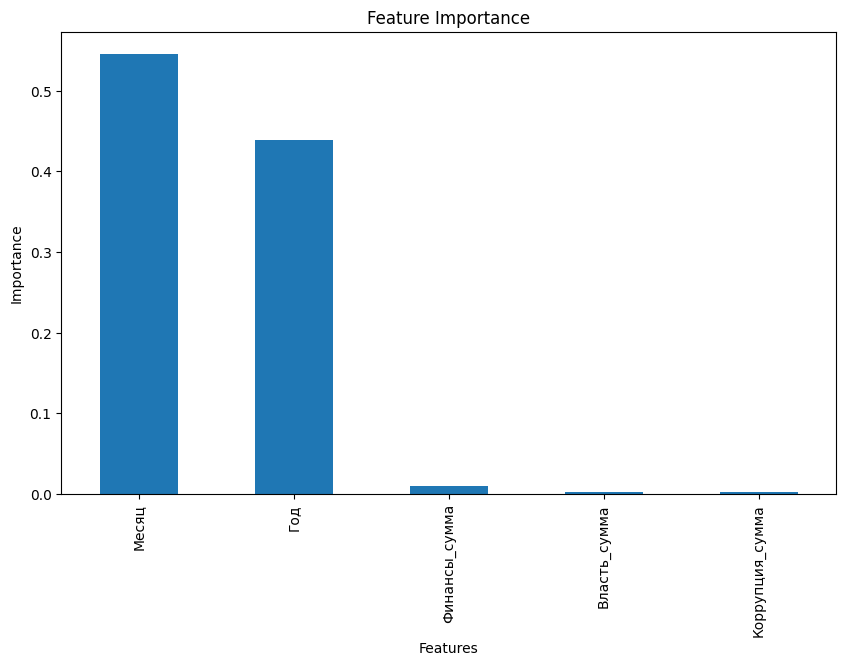

In [12]:
# Обучение модели XGBoost на агрегированных данных
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
xgb_model.fit(X_train_agg, y_train_agg)

# Вычисление важности признаков
importance = pd.Series(xgb_model.feature_importances_, index=X_agg.columns)

# Сортировка и визуализация
importance.sort_values(ascending=False).plot(kind="bar", figsize=(10, 6), title="Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

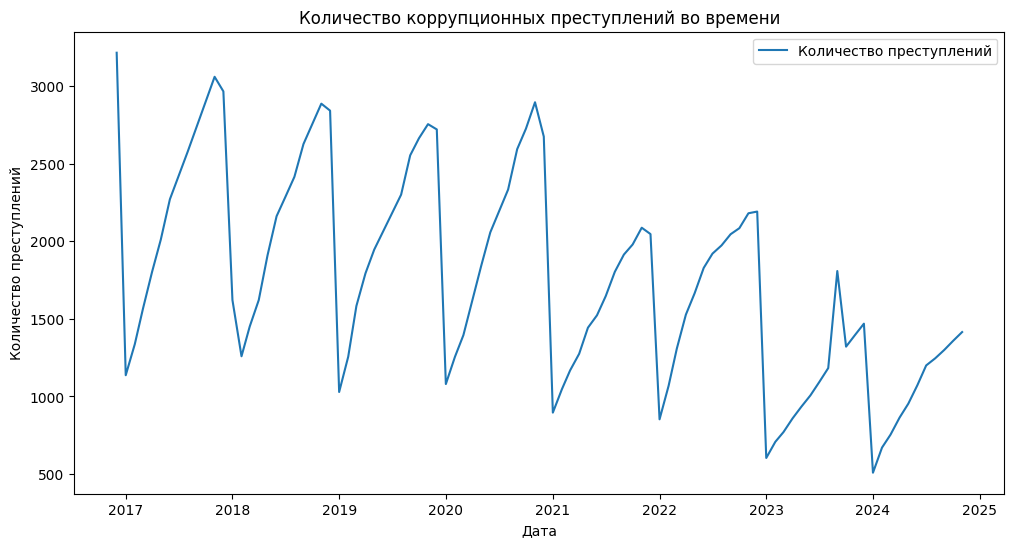

In [13]:
# Убедимся, что 'Дата' является индексом
df_agg['Дата'] = pd.to_datetime(df_agg['Год'].astype(str) + '-' + df_agg['Месяц'].astype(str))
df_agg.set_index('Дата', inplace=True)

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(df_agg.index, df_agg['Всего коррупционных преступлений'], label="Количество преступлений")
plt.title("Количество коррупционных преступлений во времени")
plt.xlabel("Дата")
plt.ylabel("Количество преступлений")
plt.legend()
plt.show()

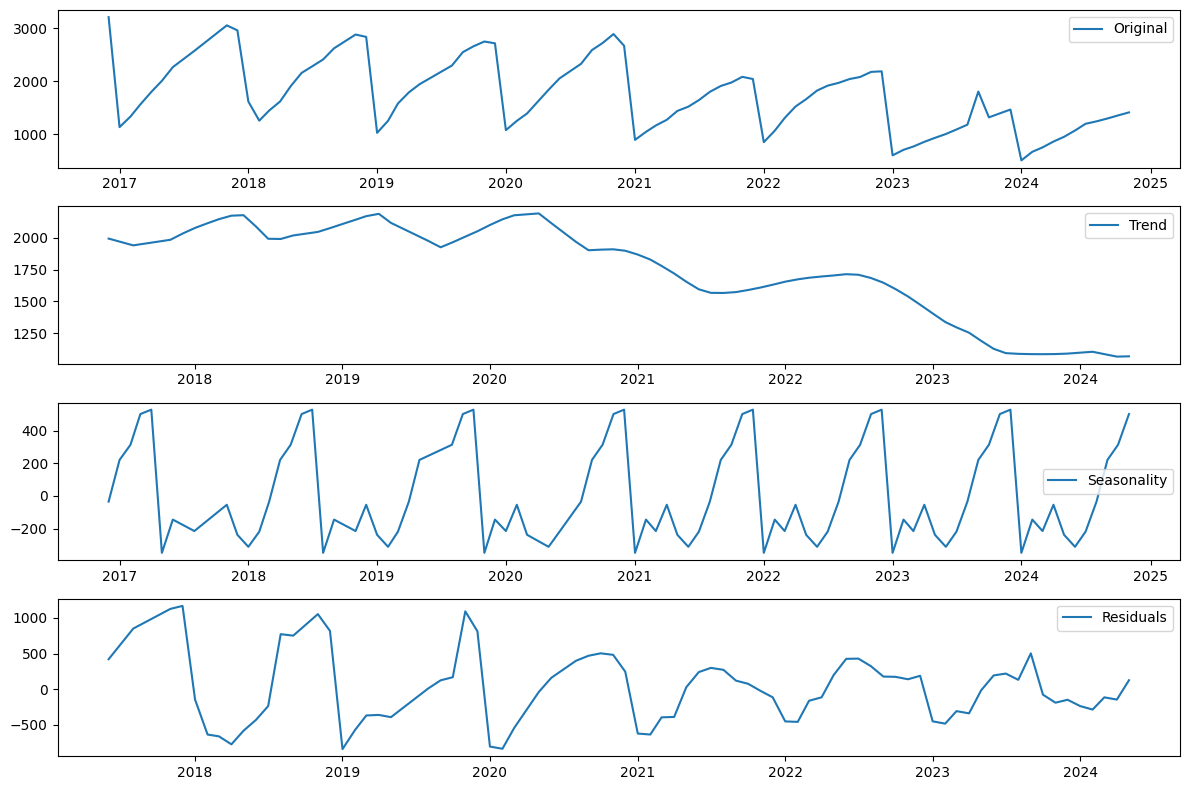

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Декомпозиция временного ряда
decomposition = seasonal_decompose(df_agg['Всего коррупционных преступлений'], model='additive', period=12)

# Визуализация компонентов
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(df_agg['Всего коррупционных преступлений'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results w

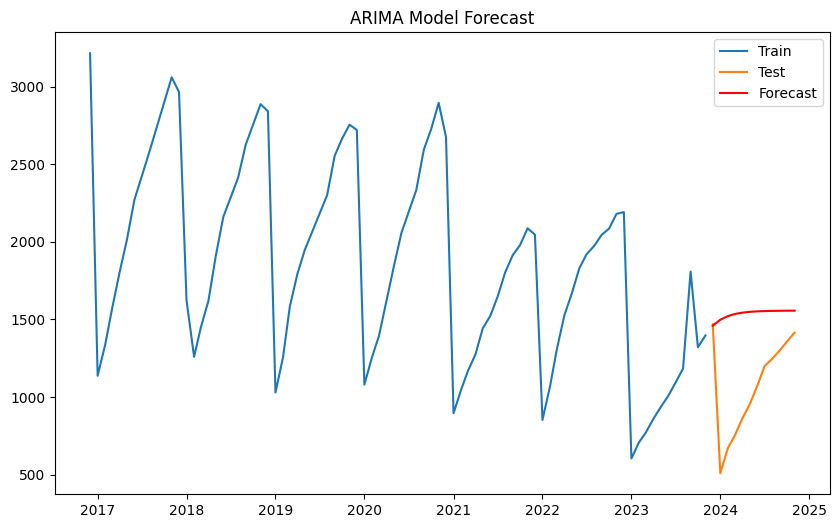

Mean Squared Error: 308358.11


In [15]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Разделяем данные на тренировочные и тестовые
train = df_agg['Всего коррупционных преступлений'][:-12]
test = df_agg['Всего коррупционных преступлений'][-12:]

# Построение модели ARIMA
model = ARIMA(train, order=(1, 1, 1))  # Параметры ARIMA(p, d, q)
model_fit = model.fit()

# Прогнозирование
forecast = model_fit.forecast(steps=12)
plt.figure(figsize=(10, 6))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast, label="Forecast", color='red')
plt.title("ARIMA Model Forecast")
plt.legend()
plt.show()

# Оценка качества прогноза
mse = mean_squared_error(test, forecast)
print(f"Mean Squared Error: {mse:.2f}")


c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
17:20:13 - cmdstanpy - INFO - Chain [1] start processing
17:20:14 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


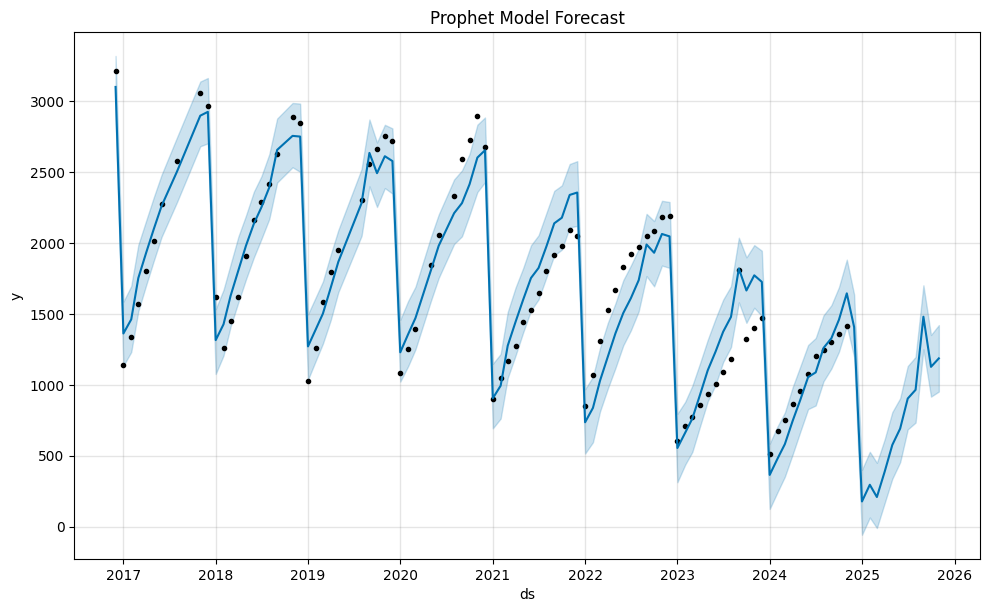

In [16]:
from prophet import Prophet

# Подготовка данных для Prophet
prophet_df = df_agg.reset_index()[['Дата', 'Всего коррупционных преступлений']]
prophet_df.columns = ['ds', 'y']  # Требования Prophet

# Обучение модели Prophet
model = Prophet()
model.fit(prophet_df)

# Прогнозирование
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

# Визуализация прогноза
fig = model.plot(forecast)
plt.title("Prophet Model Forecast")
plt.show()


In [17]:
# Извлекаем реальные тестовые значения (последние 12 месяцев)
test = prophet_df.iloc[-12:]  # Реальные значения
test = test.set_index('ds')

# Извлекаем предсказанные значения на тестовом периоде
forecast_test = forecast[['ds', 'yhat']].set_index('ds').loc[test.index]

# Вычисление метрик
mae = mean_absolute_error(test['y'], forecast_test['yhat'])
mse = mean_squared_error(test['y'], forecast_test['yhat'])
r2 = r2_score(test['y'], forecast_test['yhat'])

# Вывод результатов
print(f"Prophet Metrics:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")

Prophet Metrics:
MAE: 120.54
MSE: 20609.91
R2: 0.77


c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this m

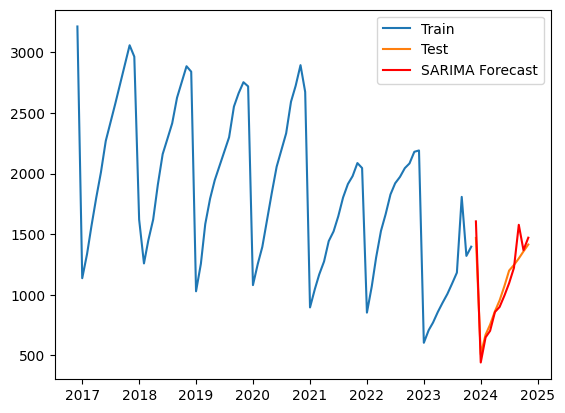

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA: Указываем сезонность period=12
model_sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit_sarima = model_sarima.fit()

forecast_sarima = model_fit_sarima.forecast(steps=12)
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast_sarima, label="SARIMA Forecast", color='red')
plt.legend()
plt.show()


In [19]:
mae = mean_absolute_error(test, forecast_sarima)
mse = mean_squared_error(test, forecast_sarima)
r2 = r2_score(test, forecast_sarima)

print(f"SARIMA Metrics:\nMAE: {mae:.2f}\nMSE: {mse:.2f}\nR2: {r2:.2f}")


SARIMA Metrics:
MAE: 73.97
MSE: 10594.50
R2: 0.88


In [20]:
# SARIMA прогноз на 12 месяцев вперёд
sarima_forecast = model_fit_sarima.forecast(steps=12)

# Преобразуем в DataFrame для удобства
sarima_forecast = pd.DataFrame({'Дата': pd.date_range(start=train.index[-1] + pd.offsets.MonthEnd(1), 
                                                     periods=12, freq='M'),
                                'SARIMA Forecast': sarima_forecast.values})

print(sarima_forecast)


         Дата  SARIMA Forecast
0  2023-11-30      1605.863677
1  2023-12-31       441.596621
2  2024-01-31       648.909951
3  2024-02-29       702.900166
4  2024-03-31       857.817330
5  2024-04-30       899.965474
6  2024-05-31       994.218392
7  2024-06-30      1096.211391
8  2024-07-31      1222.810322
9  2024-08-31      1577.513902
10 2024-09-30      1368.510436
11 2024-10-31      1471.224802


c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\asanb\AppData\Local\Temp\ipykernel_14808\835356587.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sarima_forecast = pd.DataFrame({'Дата': pd.date_range(start=train.index[-1] + pd.offsets.MonthEnd(1),


In [21]:
# Prophet прогноз на 12 месяцев вперёд
prophet_forecast = forecast[['ds', 'yhat']].iloc[-12:]  # Последние 12 месяцев прогноза

print(prophet_forecast)


           ds         yhat
88 2024-11-30  1405.482857
89 2024-12-31   177.068278
90 2025-01-31   294.858886
91 2025-02-28   208.331656
92 2025-03-31   388.293685
93 2025-04-30   575.441948
94 2025-05-31   690.462228
95 2025-06-30   902.300227
96 2025-07-31   963.787070
97 2025-08-31  1478.983956
98 2025-09-30  1125.727946
99 2025-10-31  1185.381130


c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


         Date  SARIMA Forecast
76 2023-12-31      1605.863677
77 2024-01-31       441.596621
78 2024-02-29       648.909951
79 2024-03-31       702.900166
80 2024-04-30       857.817330
81 2024-05-31       899.965474
82 2024-06-30       994.218392
83 2024-07-31      1096.211391
84 2024-08-31      1222.810322
85 2024-09-30      1577.513902
86 2024-10-31      1368.510436
87 2024-11-30      1471.224802
88 2024-12-31      1574.665870
89 2025-01-31       368.689599
90 2025-02-28       542.772919
91 2025-03-31       573.093586
92 2025-04-30       718.838444
93 2025-05-31       751.115642
94 2025-06-30       842.192467
95 2025-07-31       942.635921
96 2025-08-31      1069.965757
97 2025-09-30      1406.653617
98 2025-10-31      1214.753906
99 2025-11-30      1318.862647


c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\asanb\AppData\Local\Temp\ipykernel_14808\1738800193.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=train.index[-1], periods=forecast_steps + 1, freq='M')[1:]


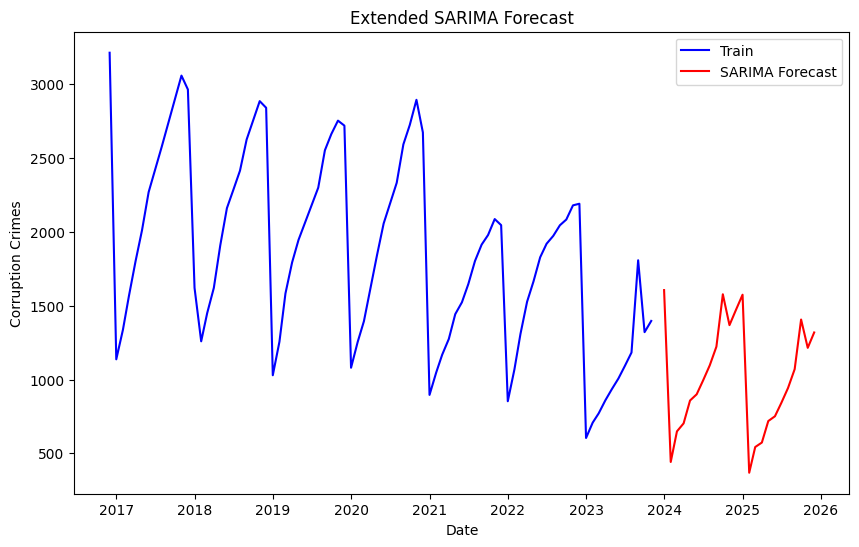

In [ ]:
# Fit the SARIMA model
model_sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit_sarima = model_sarima.fit()

# Generate forecasts for the entire range, including 2025
forecast_steps = 24  # Adjust this to include 2025 (e.g., 24 months = 2 years from the end of training data)
sarima_forecast = model_fit_sarima.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=train.index[-1], periods=forecast_steps + 1, freq='M')[1:]
sarima_forecast_values = sarima_forecast.predicted_mean

# Create a DataFrame for the SARIMA forecast
sarima_forecast_df = pd.DataFrame({
    'Date': forecast_index,
    'SARIMA Forecast': sarima_forecast_values
})

# Print the extended SARIMA forecast
print(sarima_forecast_df)

# Plot the extended forecast
plt.figure(figsize=(10, 6))
plt.plot(train, label="Train", color="blue")
plt.plot(sarima_forecast_df['Date'], sarima_forecast_df['SARIMA Forecast'], label="SARIMA Forecast", color="red")
plt.title("Extended SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Corruption Crimes")
plt.legend()
plt.show()

# Part for the Final

In [23]:
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import numpy as np

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# Выбор целевой переменной
target_column = 'Всего коррупционных преступлений'
data = df_agg[[target_column]].values  # Берем только целевой столбец

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Функция для преобразования временного ряда в набор данных для LSTM
def create_sequences(data, time_steps=12):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps, 0])
        y.append(data[i+time_steps, 0])
    return np.array(X), np.array(y)

In [ ]:
# Создание обучающих и тестовых данных
time_steps = 12  # Используем данные за последний год для предсказания
X, y = create_sequences(scaled_data, time_steps)

# Разделение на обучающую и тестовую выборки
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Преобразование данных в 3D для LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Создание модели LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

In [ ]:
# Компиляция модели
model.compile(optimizer='adam', loss='mean_squared_error')

# Обучение модели
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
2/2 [==============================] - 3s 603ms/step - loss: 0.2492 - val_loss: 0.0480
Epoch 2/50
2/2 [==============================] - 0s 30ms/step - loss: 0.1809 - val_loss: 0.0298
Epoch 3/50
2/2 [==============================] - 0s 32ms/step - loss: 0.1222 - val_loss: 0.0172
Epoch 4/50
2/2 [==============================] - 0s 34ms/step - loss: 0.0701 - val_loss: 0.0150
Epoch 5/50
2/2 [==============================] - 0s 33ms/step - loss: 0.0561 - val_loss: 0.0274
Epoch 6/50
2/2 [==============================] - 0s 31ms/step - loss: 0.0759 - val_loss: 0.0363
Epoch 7/50
2/2 [==============================] - 0s 30ms/step - loss: 0.0731 - val_loss: 0.0308
Epoch 8/50
2/2 [==============================] - 0s 34ms/step - loss: 0.0622 - val_loss: 0.0223
Epoch 9/50
2/2 [==============================] - 0s 32ms/step - loss: 0.0534 - val_loss: 0.0171
Epoch 10/50
2/2 [==============================] - 0s 31ms/step - loss: 0.0558 - val_loss: 0.0152
Epoch 11/50
2/2 [===========

In [ ]:
# Прогнозирование
y_pred = model.predict(X_test)

# Обратное преобразование предсказанных данных
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred)

1/1 [==============================] - 1s 568ms/step


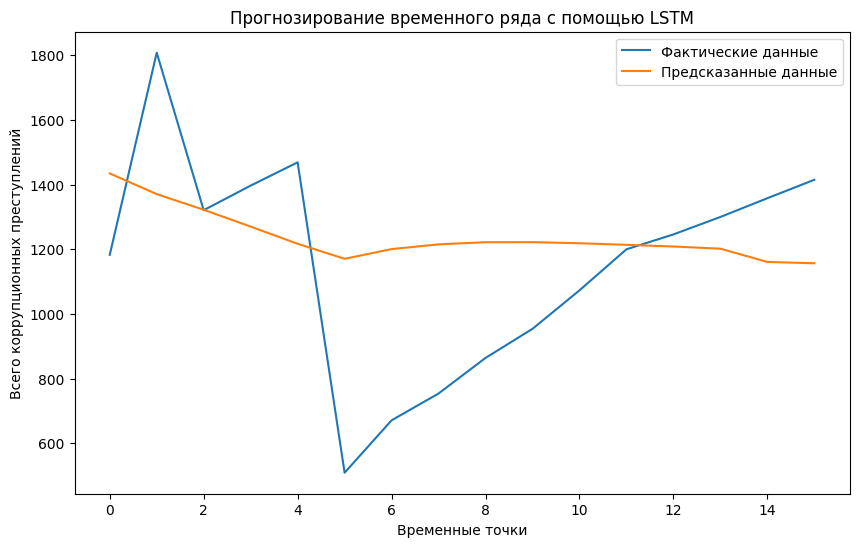

In [ ]:
# График результатов
plt.figure(figsize=(10, 6))
plt.plot(y_test_actual, label='Фактические данные')
plt.plot(y_pred_actual, label='Предсказанные данные')
plt.legend()
plt.title('Прогнозирование временного ряда с помощью LSTM')
plt.xlabel('Временные точки')
plt.ylabel(target_column)
plt.show()

In [ ]:
# Прогноз на 2025 год
future_predictions = []
last_sequence = scaled_data[-time_steps:]  # Последняя последовательность для прогноза
for _ in range(12):  # Прогноз на 12 месяцев
    pred = model.predict(last_sequence.reshape(1, time_steps, 1))
    future_predictions.append(pred[0, 0])
    last_sequence = np.append(last_sequence[1:], pred).reshape(time_steps, 1)

# Обратное преобразование прогнозов
future_predictions_actual = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Печать прогнозов
print("Прогноз на 2025 год (по месяцам):")
for i, value in enumerate(future_predictions_actual, 1):
    print(f"Месяц {i}: {value[0]:.2f}")

1/1 [==============================] - 0s 31ms/step
Прогноз на 2025 год (по месяцам):
Месяц 1: 1153.45
Месяц 2: 1142.95
Месяц 3: 1190.56
Месяц 4: 1227.17
Месяц 5: 1258.57
Месяц 6: 1283.41
Месяц 7: 1303.10
Месяц 8: 1315.88
Месяц 9: 1321.33
Месяц 10: 1324.57
Месяц 11: 1325.06
Месяц 12: 1322.55


RMSE на тестовой выборке: 269.71


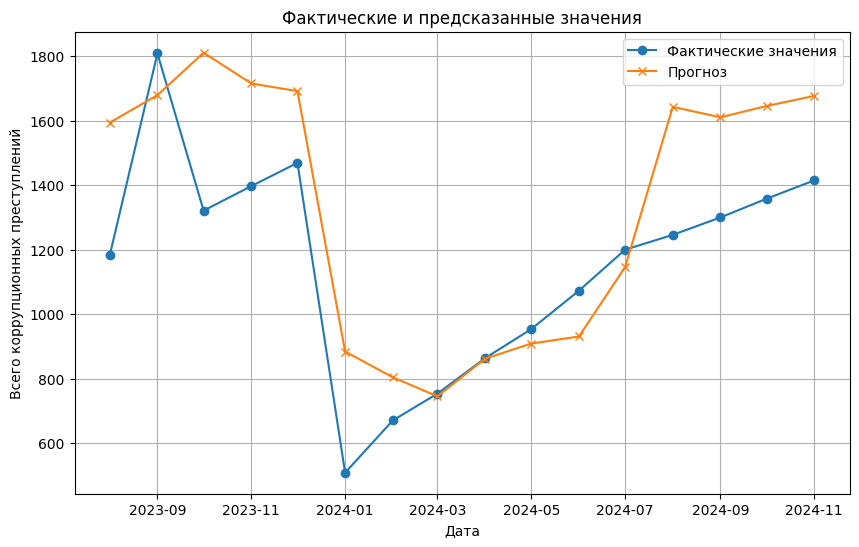

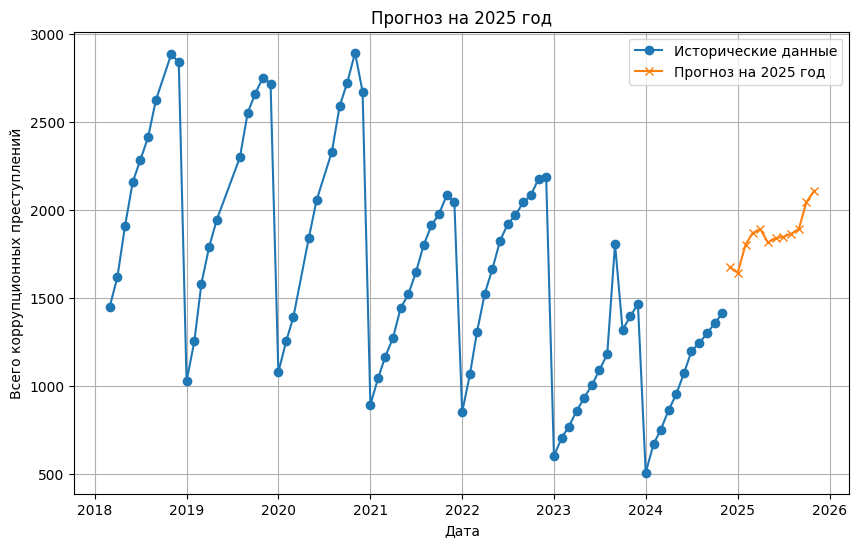

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import matplotlib.pyplot as plt

# Загрузка данных
df_agg = pd.read_csv("df_agg.csv", parse_dates=["Дата"], index_col="Дата")

# Целевая переменная
target_column = "Всего коррупционных преступлений"

# Создаем лаговые признаки
def create_lag_features(df, target_col, lags=12):
    for lag in range(1, lags + 1):
        df[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)
    return df

df_agg = create_lag_features(df_agg, target_column, lags=12)

# Удаляем строки с NaN, образовавшиеся из-за лагов
df_agg = df_agg.dropna()

# Разделяем данные на признаки и целевую переменную
X = df_agg.drop(columns=[target_column])
y = df_agg[target_column]

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Создаем и обучаем модель XGBoost
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
model.fit(X_train, y_train)

# Прогноз на тестовой выборке
y_pred = model.predict(X_test)

# Оценка качества модели
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"RMSE на тестовой выборке: {rmse:.2f}")

# График фактических и предсказанных значений
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test, label="Фактические значения", marker="o")
plt.plot(y_test.index, y_pred, label="Прогноз", marker="x")
plt.legend()
plt.title("Фактические и предсказанные значения")
plt.xlabel("Дата")
plt.ylabel(target_column)
plt.grid()
plt.show()

# Прогноз на 2025 год
future_df = df_agg.copy()

for _ in range(12):
    last_row = future_df.iloc[-1]
    next_features = last_row.drop(target_column).values.reshape(1, -1)
    next_pred = model.predict(next_features)[0]
    future_date = last_row.name + pd.DateOffset(months=1)
    new_row = {**{col: val for col, val in zip(future_df.columns, next_features[0])}, target_column: next_pred}
    future_df.loc[future_date] = new_row

# График прогноза на 2025 год
plt.figure(figsize=(10, 6))
plt.plot(df_agg.index, df_agg[target_column], label="Исторические данные", marker="o")
plt.plot(future_df.index[-12:], future_df[target_column].iloc[-12:], label="Прогноз на 2025 год", marker="x")
plt.legend()
plt.title("Прогноз на 2025 год")
plt.xlabel("Дата")
plt.ylabel(target_column)
plt.grid()
plt.show()


Epoch 1/50
4/4 - 3s - loss: 0.1265 - val_loss: 0.1039 - 3s/epoch - 811ms/step
Epoch 2/50
4/4 - 0s - loss: 0.0842 - val_loss: 0.0951 - 71ms/epoch - 18ms/step
Epoch 3/50
4/4 - 0s - loss: 0.0586 - val_loss: 0.0323 - 73ms/epoch - 18ms/step
Epoch 4/50
4/4 - 0s - loss: 0.0674 - val_loss: 0.0260 - 128ms/epoch - 32ms/step
Epoch 5/50
4/4 - 0s - loss: 0.0592 - val_loss: 0.0340 - 88ms/epoch - 22ms/step
Epoch 6/50
4/4 - 0s - loss: 0.0564 - val_loss: 0.0408 - 74ms/epoch - 18ms/step
Epoch 7/50
4/4 - 0s - loss: 0.0557 - val_loss: 0.0289 - 75ms/epoch - 19ms/step
Epoch 8/50
4/4 - 0s - loss: 0.0491 - val_loss: 0.0206 - 74ms/epoch - 18ms/step
Epoch 9/50
4/4 - 0s - loss: 0.0533 - val_loss: 0.0248 - 71ms/epoch - 18ms/step
Epoch 10/50
4/4 - 0s - loss: 0.0483 - val_loss: 0.0274 - 74ms/epoch - 18ms/step
Epoch 11/50
4/4 - 0s - loss: 0.0477 - val_loss: 0.0229 - 75ms/epoch - 19ms/step
Epoch 12/50
4/4 - 0s - loss: 0.0458 - val_loss: 0.0177 - 76ms/epoch - 19ms/step
Epoch 13/50
4/4 - 0s - loss: 0.0492 - val_loss: 0

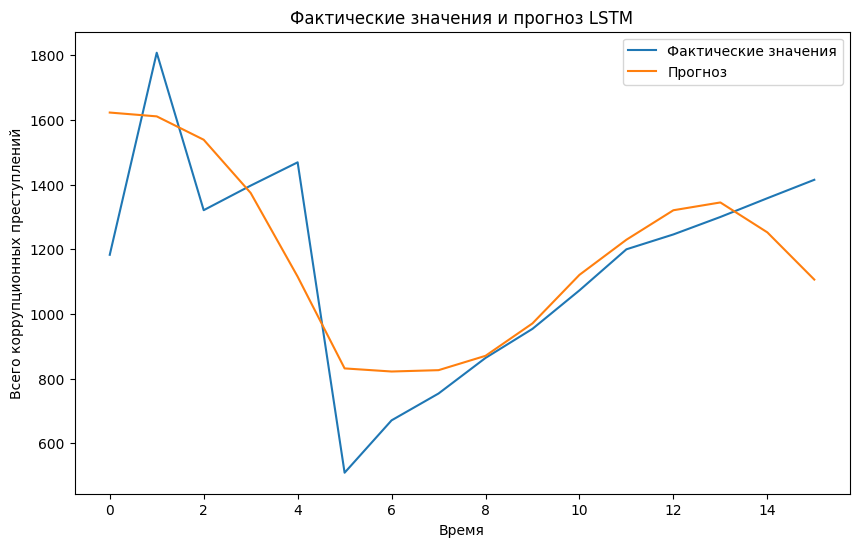

1/1 [==============================] - 0s 16ms/step


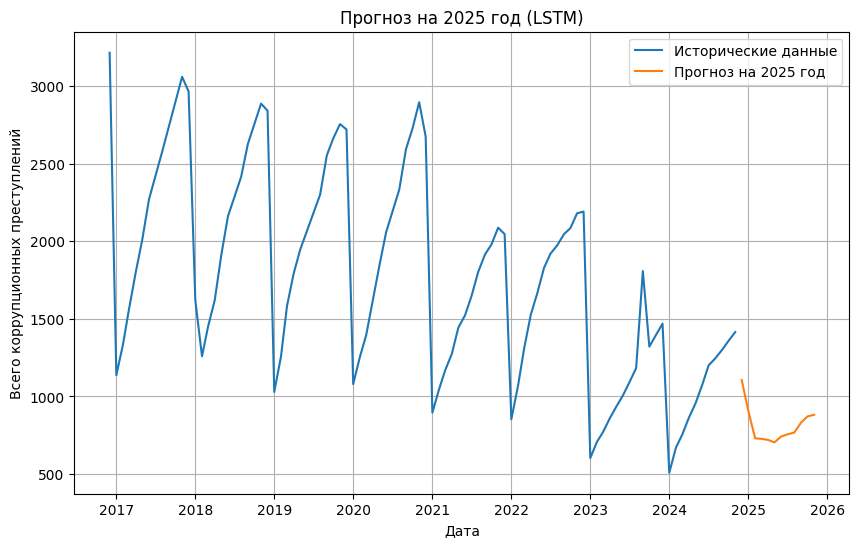

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from sklearn.metrics import mean_squared_error

# Загрузка данных
df_agg = pd.read_csv("df_agg.csv", parse_dates=["Дата"], index_col="Дата")

# Используем "Всего коррупционных преступлений" как целевую переменную
target_column = "Всего коррупционных преступлений"

# Масштабирование данных
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_agg)

# Создаем последовательности
def create_sequences(data, target_idx, sequence_length=12):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length, :])
        y.append(data[i+sequence_length, target_idx])
    return np.array(X), np.array(y)

# Целевая переменная
target_idx = list(df_agg.columns).index(target_column)
sequence_length = 12  # 12 месяцев

# Формируем данные для обучения
X, y = create_sequences(scaled_data, target_idx, sequence_length)

# Разделяем на обучающие и тестовые выборки
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Построение модели LSTM
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Обучение модели
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    verbose=2
)

# Оценка модели
y_pred = model.predict(X_test)
y_pred_rescaled = scaler.inverse_transform(np.hstack((X_test[:, -1, :-1], y_pred.reshape(-1, 1))))[:, -1]
y_test_rescaled = scaler.inverse_transform(np.hstack((X_test[:, -1, :-1], y_test.reshape(-1, 1))))[:, -1]

rmse = mean_squared_error(y_test_rescaled, y_pred_rescaled, squared=False)
print(f"RMSE: {rmse:.2f}")

# График фактических и предсказанных значений
plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled, label="Фактические значения")
plt.plot(y_pred_rescaled, label="Прогноз")
plt.legend()
plt.title("Фактические значения и прогноз LSTM")
plt.xlabel("Время")
plt.ylabel(target_column)
plt.show()

# Прогноз на 2025 год
future_steps = 12
future_predictions = []

last_sequence = X_test[-1]
for _ in range(future_steps):
    pred = model.predict(last_sequence[np.newaxis, :, :])[0]
    future_predictions.append(pred)
    last_sequence = np.vstack((last_sequence[1:], np.hstack((last_sequence[-1, :-1], pred))))

future_predictions_rescaled = scaler.inverse_transform(np.hstack((np.zeros((future_steps, X_test.shape[2]-1)), np.array(future_predictions).reshape(-1, 1))))[:, -1]

# График прогноза на 2025 год
plt.figure(figsize=(10, 6))
plt.plot(df_agg[target_column], label="Исторические данные")
future_index = pd.date_range(df_agg.index[-1], periods=future_steps+1, freq='MS')[1:]
plt.plot(future_index, future_predictions_rescaled, label="Прогноз на 2025 год")
plt.legend()
plt.title("Прогноз на 2025 год (LSTM)")
plt.xlabel("Дата")
plt.ylabel(target_column)
plt.grid()
plt.show()
